<a href="https://colab.research.google.com/github/ashwini-ah18/Artificial-Intelligence/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [24]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images:", x_train.shape)
print("Testing Images :", x_test.shape)


Training Images: (50000, 32, 32, 3)
Testing Images : (10000, 32, 32, 3)


In [25]:
# Class Names
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

In [26]:
# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


In [27]:
# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


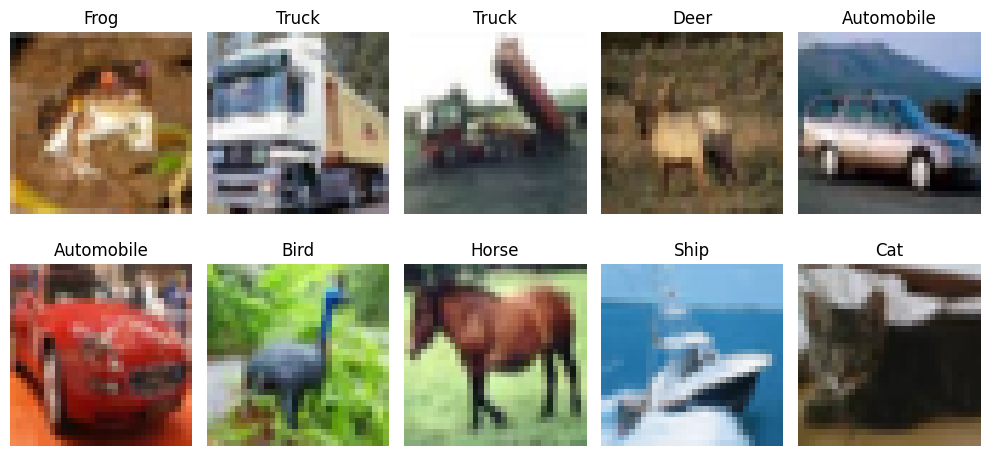

In [28]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [29]:
model = Sequential()

# Block 1
model.add(Conv2D(
    32,
    (3,3),
    padding='same',
    activation='relu',
    input_shape=(32,32,3)
))
model.add(BatchNormalization())

model.add(Conv2D(
    32,
    (3,3),
    activation='relu'
))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
# Block 2
model.add(Conv2D(
    64,
    (3,3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())

model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Fully Connected Layers
model.add(Flatten())

model.add(Dense(
    512,
    activation='relu'
))
model.add(Dropout(0.5))

model.add(Dense(
    10,
    activation='softmax'
))

In [32]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,251,242 (4.77 MB)

 Trainable params: 1,251,050 (4.77 MB)

 Non-trainable params: 192 (768.00 B)

In [33]:
history = model.fit(
    x_train,
    y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4047 - loss: 1.6680 - val_accuracy: 0.4871 - val_loss: 1.4738
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5571 - loss: 1.2384 - val_accuracy: 0.6112 - val_loss: 1.0749
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6314 - loss: 1.0492 - val_accuracy: 0.6797 - val_loss: 0.9127
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6709 - loss: 0.9387 - val_accuracy: 0.6775 - val_loss: 0.9109
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7023 - loss: 0.8526 - val_accuracy: 0.6998 - val_loss: 0.8910
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7215 - loss: 0.7985 - val_accuracy: 0.7442 - val_loss: 0.7258
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7389 - loss: 0.7478 - val_accuracy: 0.7335 - val_loss: 0.7686
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7527 - loss: 0.7123 - val_accuracy: 

In [34]:
test_loss, test_acc = model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print("\nTest Accuracy:", round(test_acc*100,2), "%")
print("Test Loss:", round(test_loss,4))


Test Accuracy: 79.26 %
Test Loss: 0.6454


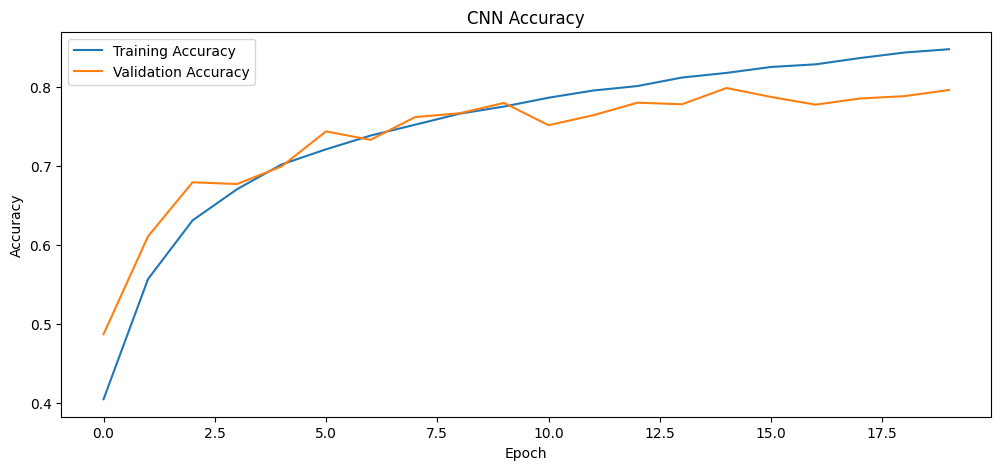

In [35]:
plt.figure(figsize=(12,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()


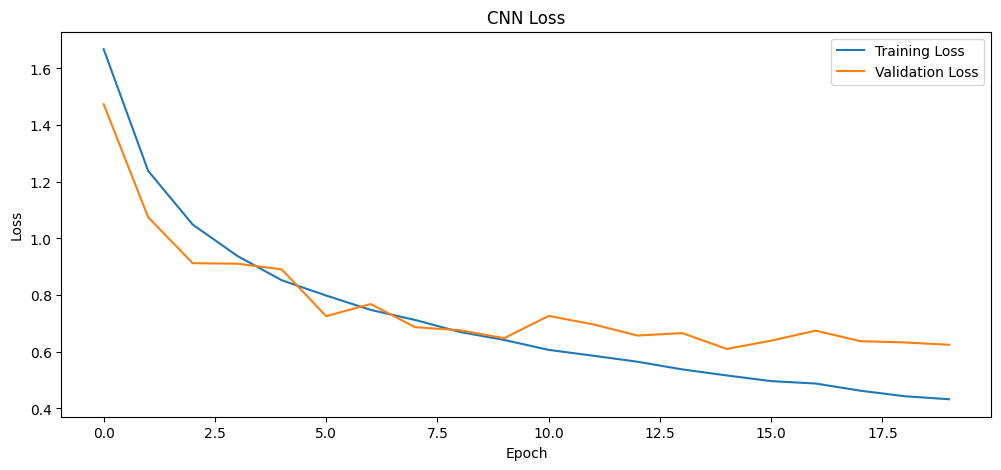

In [36]:
# Plot Loss
# ==========================================

plt.figure(figsize=(12,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()
plt.show()

In [37]:
# Predictions
# ==========================================

y_pred_prob = model.predict(x_test)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = y_test.flatten()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [38]:
# Classification Report
# ==========================================

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


Classification Report

              precision    recall  f1-score   support

    Airplane       0.78      0.84      0.81      1000
  Automobile       0.91      0.88      0.89      1000
        Bird       0.78      0.64      0.70      1000
         Cat       0.65      0.62      0.64      1000
        Deer       0.71      0.80      0.75      1000
         Dog       0.72      0.72      0.72      1000
        Frog       0.81      0.85      0.83      1000
       Horse       0.80      0.87      0.83      1000
        Ship       0.94      0.82      0.87      1000
       Truck       0.84      0.90      0.87      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



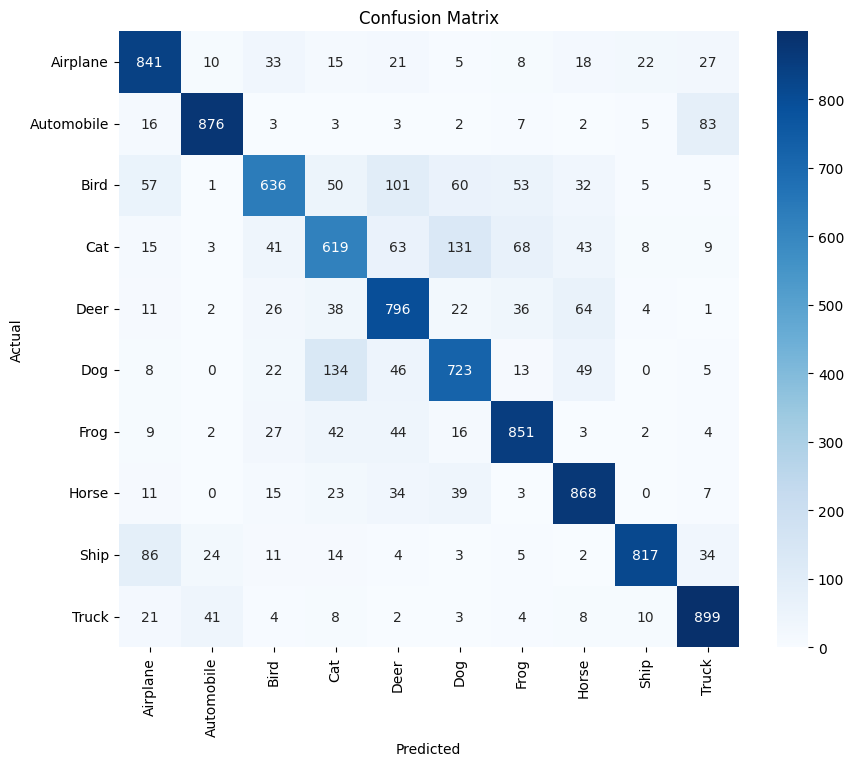

In [39]:
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

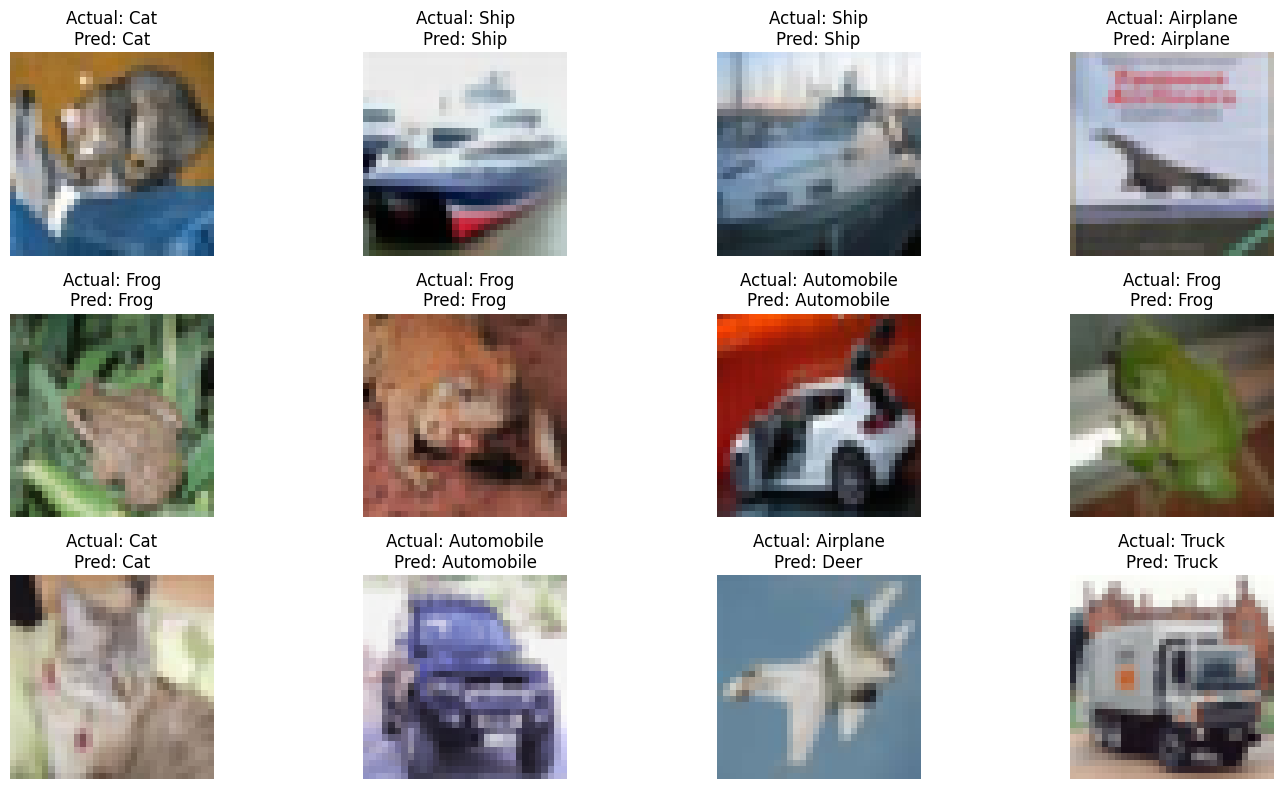

In [40]:
# Show Sample Predictions
# ==========================================

plt.figure(figsize=(15,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(x_test[i])

    plt.title(
        f"Actual: {class_names[y_true[i]]}\n"
        f"Pred: {class_names[y_pred[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()


In [41]:
# Save Model
# ==========================================

model.save("cifar10_cnn_model.h5")

print("Model saved successfully!")

Model saved successfully!
